<a href="https://colab.research.google.com/github/agrawalreva/idx-exchange-ds34/blob/main/Updated_Light_GBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt


In [65]:
df = pd.read_csv("final_training.csv", nrows = 5000) #worried collab  would crash

In [66]:
#feature engineering

#var for the median price-per-square-foot for each zipcode
df['zipcode_median_price_per_sqft'] = (
    df.groupby('PostalCode')['ClosePrice'].transform('median') /
    df.groupby('PostalCode')['LivingArea'].transform('median')
)
#for each zip code, compute median price and compute median living area
#cavea: this feature is used both internal training and internal testing set from final_training.csv

def evaluate_model(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n{label} Metrics:")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MdAPE (Median % Error): {mdape:.2f}%")
    print(f"  MAPE (Mean % Error): {mape:.2f}%")
    return rmse, r2, mdape, mape

#4  performance metrics:
#RMSE: how far off your predictions are on average, but with big mistakes punished extra hard (lower RMSE is better)
#R²: how much of the variation in house prices can the model explain (model fit)
#MDAPE: median absolute percentage error (more robust than MAPE)
#MAPE: how far off were you, expressed as a percent? (more sensitive when prices are low)



LightGBM Model (Single Feature)
Predicting ClosePrice using: LivingArea


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Single-Feature Training Metrics:
  RMSE: $792,348.19
  R²: 0.4332
  MdAPE (Median % Error): 33.73%
  MAPE (Mean % Error): 50.61%

Single-Feature Testing Metrics:
  RMSE: $825,794.99
  R²: 0.3045
  MdAPE (Median % Error): 34.01%
  MAPE (Mean % Error): 51.00%


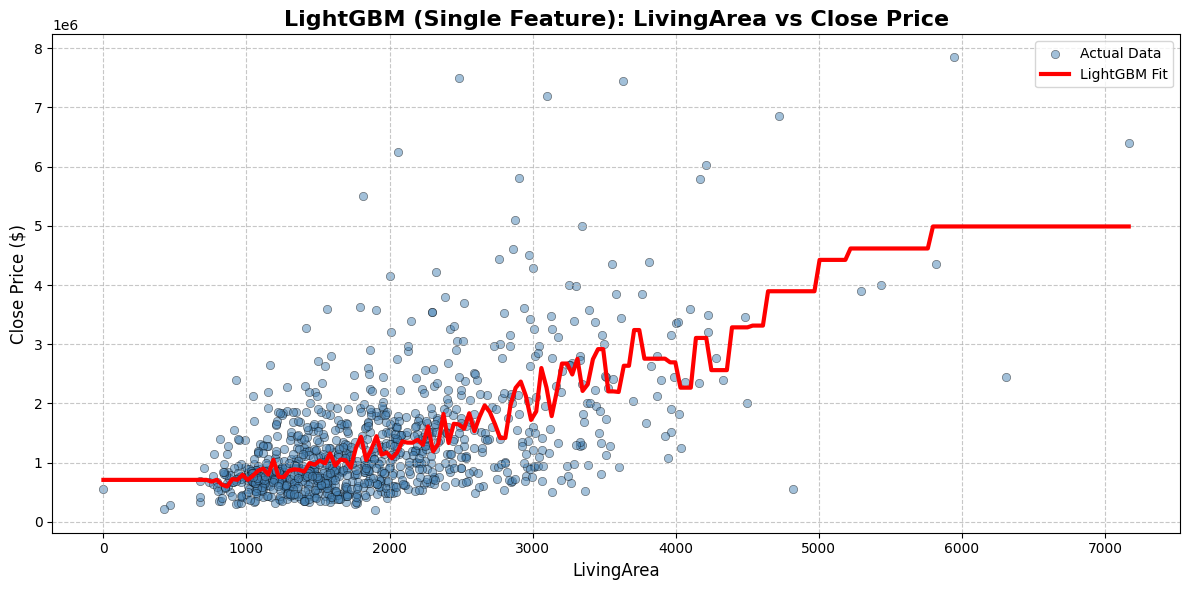

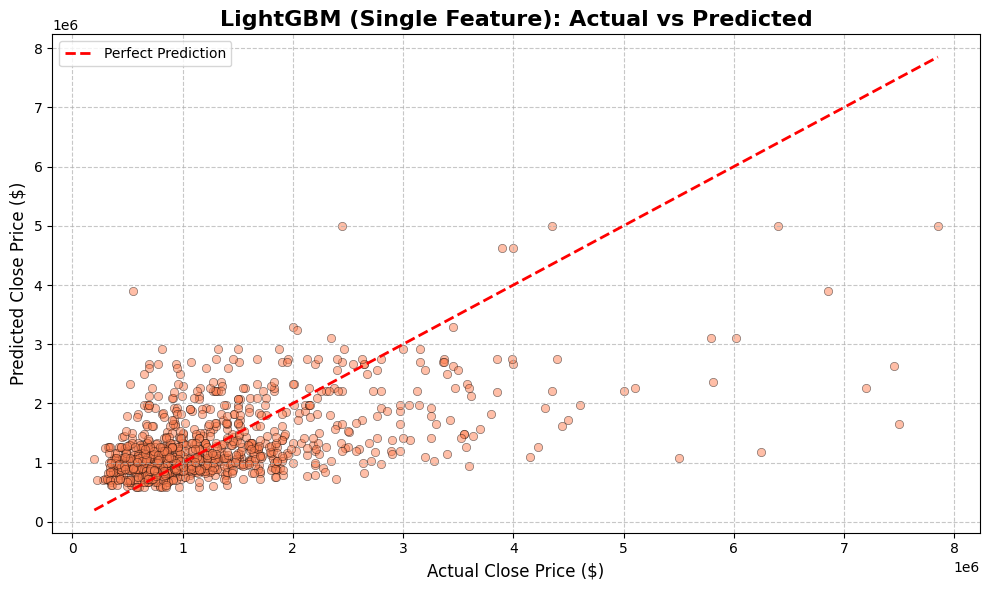

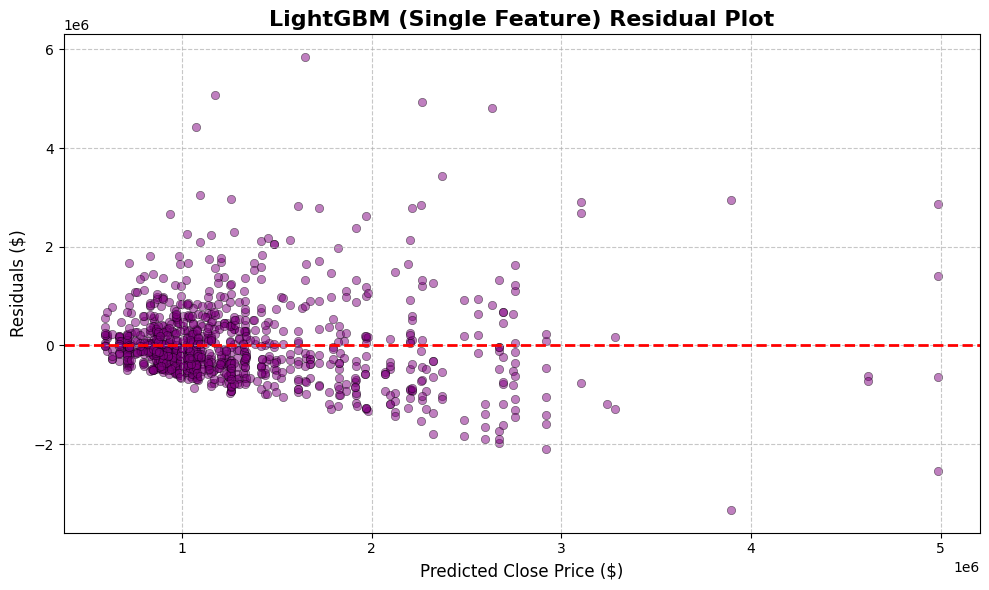


LightGBM single-feature model complete!
Predictions saved to 'lightgbm_LivingArea_single_feature_predictions.csv'


In [67]:
# 1) SINGLE-FEATURE LIGHTGBM: LivingArea → ClosePrice NOT USING TESTING DATA
feature_name = 'LivingArea'
#only one: LivingArea
print("\nLightGBM Model (Single Feature)")
print("Predicting ClosePrice using:", feature_name)
print("="*60)

X_single = df[[feature_name]].copy()
y_single = df['ClosePrice'].copy()

#replace missing values in X with the median of the column, vice versa
X_single = X_single.fillna(X_single.median())
y_single = y_single.fillna(y_single.median())
X_single = X_single.dropna()
#align y with the rows of X
y_single = y_single[X_single.index]

# 80% training
# 20% testing
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y_single, test_size=0.2, random_state=42
)

# standardize values so LightGBM can learn more smoothly --> subtract mean and divide by sd
scaler = StandardScaler()
X_train_s_scaled = scaler.fit_transform(X_train_s)
X_test_s_scaled = scaler.transform(X_test_s)

#LightGBM model
model_single = LGBMRegressor(
    n_estimators=450,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    max_depth=-1,
    random_state=42,
    verbose=-1
)
#train
model_single.fit(X_train_s_scaled, y_train_s)

#predict on training
y_train_pred_s = model_single.predict(X_train_s_scaled)
#predict on testing
y_test_pred_s = model_single.predict(X_test_s_scaled)

#call function
train_rmse_s, train_r2_s, train_mdape_s, train_mape_s  = evaluate_model(
    y_train_s, y_train_pred_s, "Single-Feature Training"
)
test_rmse_s, test_r2_s, test_mdape_s, test_mape_s = evaluate_model(
    y_test_s, y_test_pred_s, "Single-Feature Testing"
)

#plot LivingArea vs ClosePrice
plt.figure(figsize=(12, 6))
plt.scatter(X_test_s, y_test_s, alpha=0.5, color='steelblue', edgecolors='black', linewidth=0.5, label='Actual Data')
#smooth curve of predicted prices across the feature range
X_range = np.linspace(X_test_s.min(), X_test_s.max(), 200).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)
y_pred_curve = model_single.predict(X_range_scaled)
#plot LightGBM prediction curve
plt.plot(X_range, y_pred_curve, 'r-', linewidth=3, label='LightGBM Fit')
plt.xlabel(feature_name, fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.title(f'LightGBM (Single Feature): {feature_name} vs Close Price', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test_s, y_test_pred_s, alpha=0.5, color='coral', edgecolors='black', linewidth=0.5)
plt.plot([y_test_s.min(), y_test_s.max()], [y_test_s.min(), y_test_s.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Close Price ($)', fontsize=12)
plt.ylabel('Predicted Close Price ($)', fontsize=12)
plt.title('LightGBM (Single Feature): Actual vs Predicted', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# residual plot
residuals_s = y_test_s - y_test_pred_s
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred_s, residuals_s, alpha=0.5, color='purple', edgecolors='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Close Price ($)', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title('LightGBM (Single Feature) Residual Plot', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# table summarizing actual vs predicted vs residuals
results_single = pd.DataFrame({
    feature_name: X_test_s.values.flatten(),
    'Actual_Price': y_test_s.values,
    'Predicted_Price': y_test_pred_s,
    'Residual': residuals_s
})
results_single.to_csv(f'lightgbm_{feature_name}_single_feature_predictions.csv', index=False)

print("\nLightGBM single-feature model complete!")
print(f"Predictions saved to 'lightgbm_{feature_name}_single_feature_predictions.csv'")


LightGBM Model (Full Feature Set)
Predicting ClosePrice using: all available predictors

Full-Feature Training Metrics:
  RMSE: $112,326.24
  R²: 0.9886
  MdAPE (Median % Error): 5.11%
  MAPE (Mean % Error): 7.04%

Full-Feature Testing Metrics:
  RMSE: $358,091.08
  R²: 0.8692
  MdAPE (Median % Error): 10.75%
  MAPE (Mean % Error): 14.89%


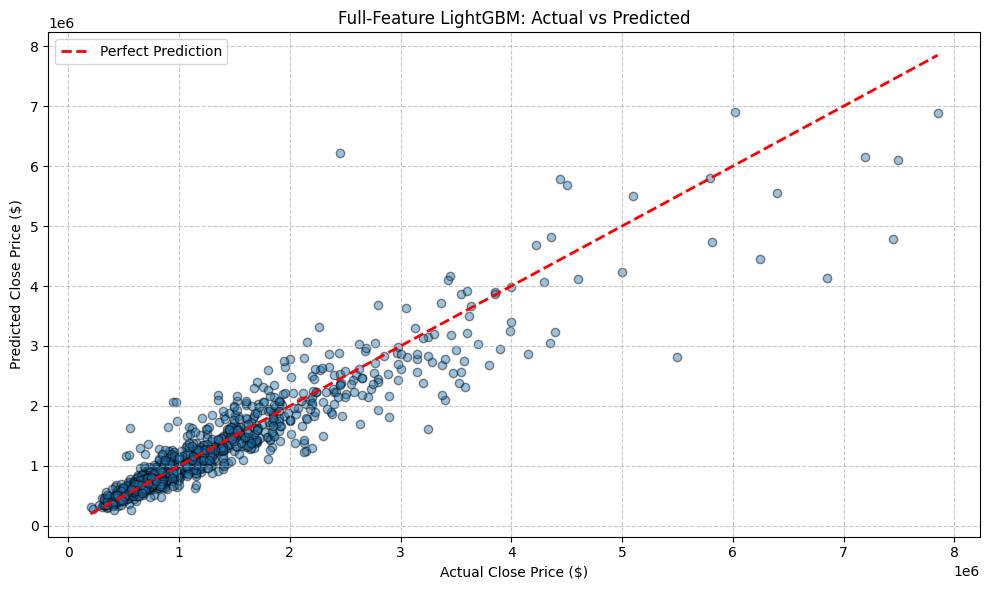

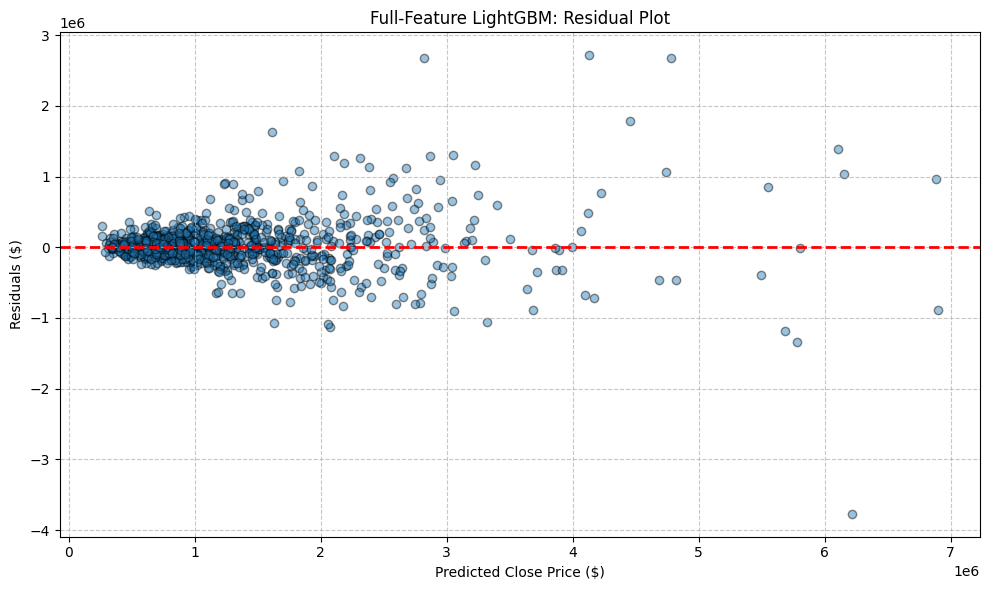

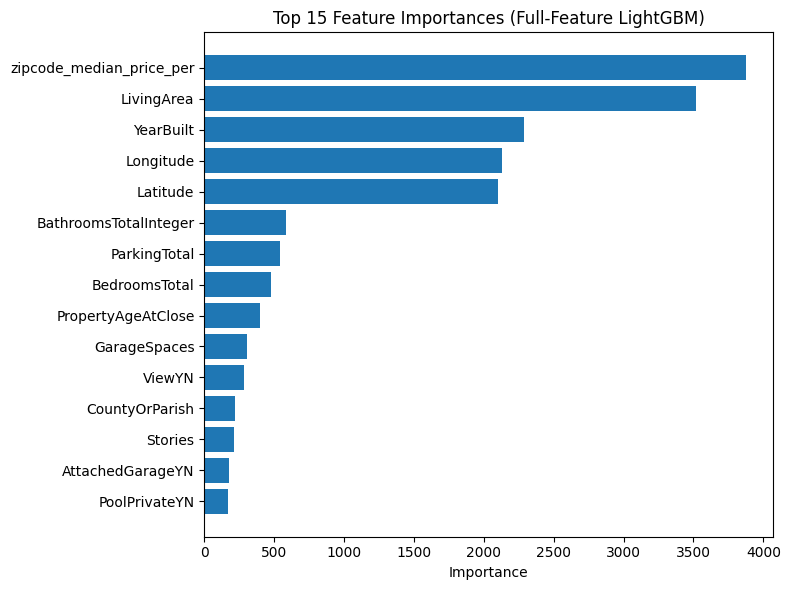


===== Aggregated Feature Importance by Original Feature =====
zipcode_median_price_per: 3874
LivingArea: 3516
YearBuilt: 2291
Longitude: 2133
Latitude: 2102
ListingContractDate: 1127
PurchaseContractDate: 895
ContractStatusChangeDate: 729
CountyOrParish: 614
BathroomsTotalInteger: 587
ParkingTotal: 542
BedroomsTotal: 477
City: 444
PropertyAgeAtClose: 398
GarageSpaces: 308
ViewYN: 286
Stories: 213
AttachedGarageYN: 180
PoolPrivateYN: 169
FireplaceYN: 93
NewConstructionYN: 18
PostalCode: 4

Full-feature LightGBM complete!
Predictions saved to 'lightgbm_full_feature_results.csv'


In [68]:
# 2) FULL-FEATURE LIGHTGBM: all dataset features + engineered features

print("\nLightGBM Model (Full Feature Set)")
print("Predicting ClosePrice using: all available predictors")
print("="*60)

# target variable
y_full = df['ClosePrice'].astype(float)

# predictor variables (all except ClosePrice + CloseDate)
X_full = df.drop(columns=['ClosePrice', 'CloseDate'])

num_cols = X_full.select_dtypes(include=[np.number]).columns
cat_cols = X_full.select_dtypes(exclude=[np.number]).columns

# fill numeric missing values with the median of each column
X_full[num_cols] = X_full[num_cols].fillna(X_full[num_cols].median())

# fill categorical missing values with the placeholder "Missing"
for c in cat_cols:
    X_full[c] = X_full[c].fillna("Missing")

# OHE
X_full = pd.get_dummies(X_full, columns=cat_cols, drop_first=True)

# Replace missing ClosePrice values with its median
y_full = y_full.fillna(y_full.median())

X_full = X_full.loc[y_full.index]

#testing dataset 20%
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full,
    test_size=0.2,
    random_state=42
)



model_full = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

model_full.fit(X_train_f, y_train_f)

#make predictions
y_train_pred_f = model_full.predict(X_train_f)
y_test_pred_f  = model_full.predict(X_test_f)



# evaluate_model must now return: RMSE, R², MdAPE, MAPE
train_rmse_f, train_r2_f, train_mdape_f, train_mape_f = evaluate_model(
    y_train_f, y_train_pred_f, "Full-Feature Training"
)

test_rmse_f, test_r2_f, test_mdape_f, test_mape_f = evaluate_model(
    y_test_f, y_test_pred_f, "Full-Feature Testing"
)


plt.figure(figsize=(10, 6))

#comparing true vs predicted prices
plt.scatter(
    y_test_f, y_test_pred_f,
    alpha=0.45,
    edgecolors='black'
)

plt.plot(
    [y_test_f.min(), y_test_f.max()],
    [y_test_f.min(), y_test_f.max()],
    'r--', linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Full-Feature LightGBM: Actual vs Predicted")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


#residual plot
resid_f = y_test_f - y_test_pred_f

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_pred_f, resid_f,
    alpha=0.45,
    edgecolors='black'
)

# zero error reference line
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.xlabel("Predicted Close Price ($)")
plt.ylabel("Residuals ($)")
plt.title("Full-Feature LightGBM: Residual Plot")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


fi_all = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance": model_full.feature_importances_
}).sort_values("Importance", ascending=False)

fi_all["CleanFeature"] = fi_all["Feature"].apply(lambda x: x.rsplit("_", 1)[0])

fi_top15 = fi_all.head(15)
plt.figure(figsize=(8, 6))
plt.barh(fi_top15["CleanFeature"][::-1], fi_top15["Importance"][::-1])
plt.title("Top 15 Feature Importances (Full-Feature LightGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# fi_all already has Feature, Importance, CleanFeature
grouped_importance = (
    fi_all.groupby("CleanFeature")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\n===== Aggregated Feature Importance by Original Feature =====")
for name, imp in grouped_importance.items():
    print(f"{name}: {imp}")


results_full = pd.DataFrame({
    "Actual_Price": y_test_f.values,
    "Predicted_Price": y_test_pred_f,
    "Residual": resid_f
})

results_full.to_csv("lightgbm_full_feature_results.csv", index=False)

print("\nFull-feature LightGBM complete!")
print("Predictions saved to 'lightgbm_full_feature_results.csv'")


In [70]:
# 4) REDUCED-FEATURE LIGHTGBM: drop predictors with importance < 20
 #FINE TUNING

print("\nLightGBM Model (Reduced Feature Set — Importance < 20 removed)")
print("Dropping predictors with importance less than 20")
print("="*60)

# choose the threshold #tried 50 #maybe further fine tuning between 20-50
importance_threshold = 20

low_imp_features = fi_all[fi_all["Importance"] < importance_threshold]["Feature"].tolist()

print(f"Original number of predictors: {X_full.shape[1]}")
print(f"Number of predictors with importance < {importance_threshold}: {len(low_imp_features)}")

#drop low-importance predictors
X_full_reduced2 = X_full.drop(columns=low_imp_features)

print(f"Number of predictors AFTER reduction: {X_full_reduced2.shape[1]}")

#new train/test split (same random_state for fairness)
X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_full_reduced2, y_full,
    test_size=0.2,
    random_state=42
)

#fit LightGBM
model_reduced2 = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

model_reduced2.fit(X_train_r2, y_train_r2)

#predictions
y_train_pred_r2 = model_reduced2.predict(X_train_r2)
y_test_pred_r2  = model_reduced2.predict(X_test_r2)

# evaluation
print("\n=== REDUCED MODEL (IMPORTANCE < 20 REMOVED) ===")
train_rmse_r2, train_r2_r2, train_mdape_r2, train_mape_r2 = evaluate_model(
    y_train_r2, y_train_pred_r2, "Reduced-Feature Training (<20)"
)

test_rmse_r2, test_r2_r2, test_mdape_r2, test_mape_r2 = evaluate_model(
    y_test_r2, y_test_pred_r2, "Reduced-Feature Testing (<20)"
)






LightGBM Model (Reduced Feature Set — Importance < 20 removed)
Dropping predictors with importance less than 20
Original number of predictors: 1733
Number of predictors with importance < 20: 1644
Number of predictors AFTER reduction: 89

=== REDUCED MODEL (IMPORTANCE < 20 REMOVED) ===

Reduced-Feature Training (<20) Metrics:
  RMSE: $113,818.00
  R²: 0.9883
  MdAPE (Median % Error): 5.08%
  MAPE (Mean % Error): 7.09%

Reduced-Feature Testing (<20) Metrics:
  RMSE: $354,490.74
  R²: 0.8718
  MdAPE (Median % Error): 11.05%
  MAPE (Mean % Error): 14.78%


In [60]:
#4) # USING TESTING DATA SET FROM TXT FILE ON REDUCED MODEL (<20)
df_test = pd.read_csv("oct_testing.txt")

#print(df_test.columns.tolist())

# recompute engineered feature
df_test['zipcode_median_price_per_sqft'] = (
    df_test.groupby('PostalCode')['ClosePrice'].transform('median') /
    df_test.groupby('PostalCode')['LivingArea'].transform('median')
)

# remove extreme outliers only on test set
lower_q = df_test['ClosePrice'].quantile(0.005)
upper_q = df_test['ClosePrice'].quantile(0.995)

df_test_filtered = df_test[
    (df_test['ClosePrice'] >= lower_q) &
    (df_test['ClosePrice'] <= upper_q)
].copy()

# separate predictors + target
X_new = df_test_filtered.drop(columns=['ClosePrice', 'CloseDate'])
y_new = df_test_filtered['ClosePrice']

# keep only numeric + categorical columns that exist in the test set
num_cols_new = [c for c in num_cols if c in X_new.columns]
cat_cols_new = [c for c in cat_cols if c in X_new.columns]

#use median to fill na
X_new[num_cols_new] = X_new[num_cols_new].fillna(X_full[num_cols_new].median())

# categorical imputations
for c in cat_cols_new:
    X_new[c] = X_new[c].fillna("Missing")

#OHE
X_new = pd.get_dummies(X_new, columns=cat_cols_new, drop_first=True)

#match reduced model's feature columns
X_new = X_new.reindex(columns=X_full_reduced2.columns, fill_value=0)

#predictions using reduced model
y_new_pred = model_reduced2.predict(X_new)

#evaluate
new_rmse, new_r2, new_mdape, new_mape = evaluate_model(
    y_new, y_new_pred, "Filtered External Test Set (Reduced Model <20)"
)



Filtered External Test Set (Reduced Model <20) Metrics:
  RMSE: $357,935.61
  R²: 0.8479
  MdAPE (Median % Error): 11.36%
  MAPE (Mean % Error): 15.24%


In [71]:
# 5) SUMMARY TABLE OF MODEL PERFORMANCE (Single, Full, Reduced <20, External Test)

summary_rows = [
    {
        "Model": "Single-Feature LightGBM",
        "Split": "Train",
        "RMSE": train_rmse_s,
        "R2": train_r2_s,
        "MdAPE": train_mdape_s,
        "MAPE": train_mape_s,
    },
    {
        "Model": "Single-Feature LightGBM",
        "Split": "Test",
        "RMSE": test_rmse_s,
        "R2": test_r2_s,
        "MdAPE": test_mdape_s,
        "MAPE": test_mape_s,
    },

    {
        "Model": "Full-Feature LightGBM",
        "Split": "Train",
        "RMSE": train_rmse_f,
        "R2": train_r2_f,
        "MdAPE": train_mdape_f,
        "MAPE": train_mape_f,
    },
    {
        "Model": "Full-Feature LightGBM",
        "Split": "Test",
        "RMSE": test_rmse_f,
        "R2": test_r2_f,
        "MdAPE": test_mdape_f,
        "MAPE": test_mape_f,
    },

    {
        "Model": "Reduced LightGBM (<20 Importance)",
        "Split": "Train",
        "RMSE": train_rmse_r2,
        "R2": train_r2_r2,
        "MdAPE": train_mdape_r2,
        "MAPE": train_mape_r2,
    },
    {
        "Model": "Reduced LightGBM (<20 Importance)",
        "Split": "Test",
        "RMSE": test_rmse_r2,
        "R2": test_r2_r2,
        "MdAPE": test_mdape_r2,
        "MAPE": test_mape_r2,
    },

    #  TXT Test — only <20 model was used
    {
        "Model": "Reduced LightGBM (<20 Importance)",
        "Split": "External Test (TXT)",
        "RMSE": new_rmse,
        "R2": new_r2,
        "MdAPE": new_mdape,
        "MAPE": new_mape,
    },
]

summary_df = pd.DataFrame(summary_rows)

print("\n========== FINAL MODEL COMPARISON SUMMARY ==========")
print(summary_df)

summary_df.to_csv("lightgbm_model_comparison_summary.csv", index=False)
print("\nModel comparison table saved to 'lightgbm_model_comparison_summary.csv'")



========== FINAL MODEL COMPARISON SUMMARY ==========
                               Model                Split           RMSE  \
0            Single-Feature LightGBM                Train  792348.189097   
1            Single-Feature LightGBM                 Test  825794.991422   
2              Full-Feature LightGBM                Train  112326.242113   
3              Full-Feature LightGBM                 Test  358091.080732   
4  Reduced LightGBM (<20 Importance)                Train  113817.999305   
5  Reduced LightGBM (<20 Importance)                 Test  354490.735260   
6  Reduced LightGBM (<20 Importance)  External Test (TXT)  357935.609317   

         R2      MdAPE       MAPE  
0  0.433187  33.727361  50.608555  
1  0.304519  34.009406  51.000281  
2  0.988609   5.114893   7.040960  
3  0.869224  10.745019  14.889322  
4  0.988304   5.080679   7.094309  
5  0.871841  11.053140  14.777230  
6  0.847924  11.358144  15.242247  

Model comparison table saved to 'lightgbm_model_


Number of numeric features: 11
Number of categorical features: 11


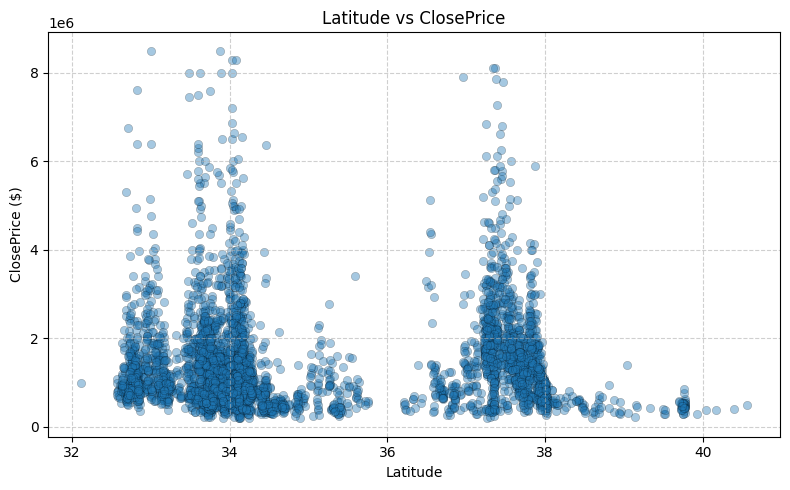

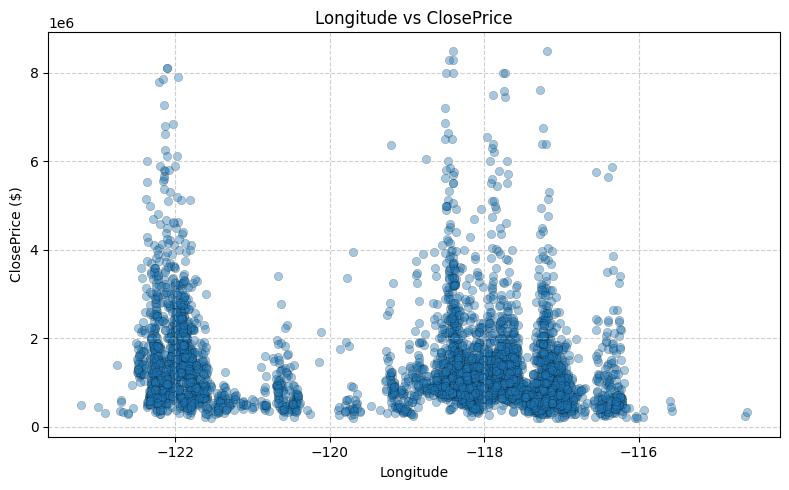

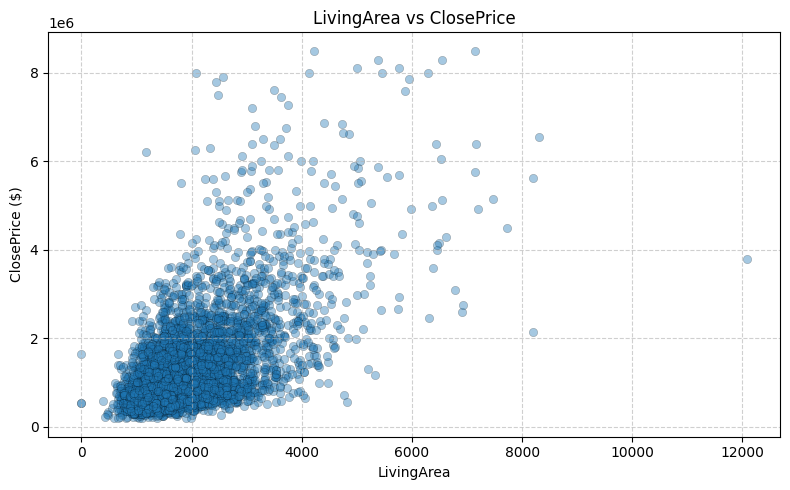

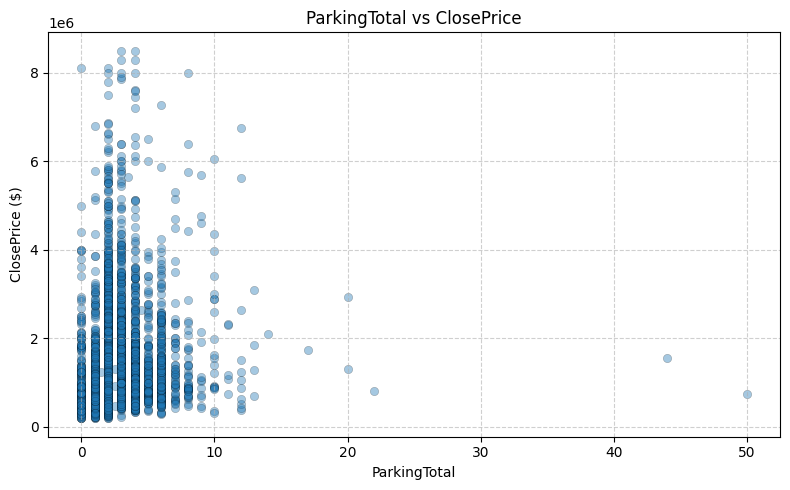

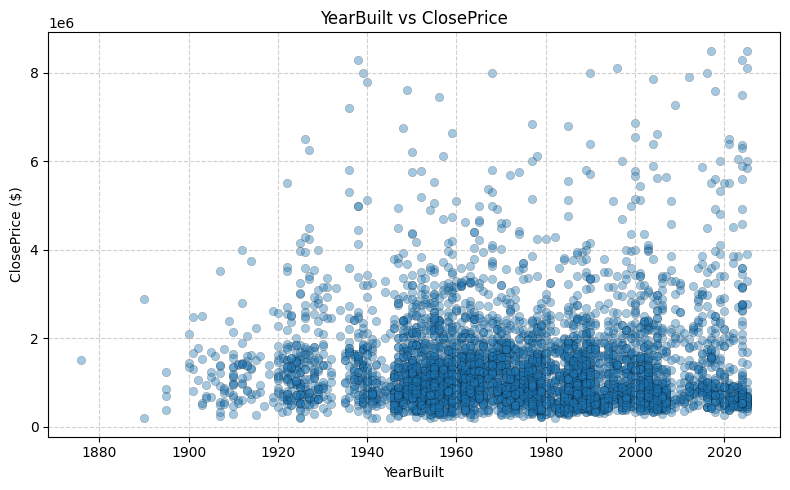

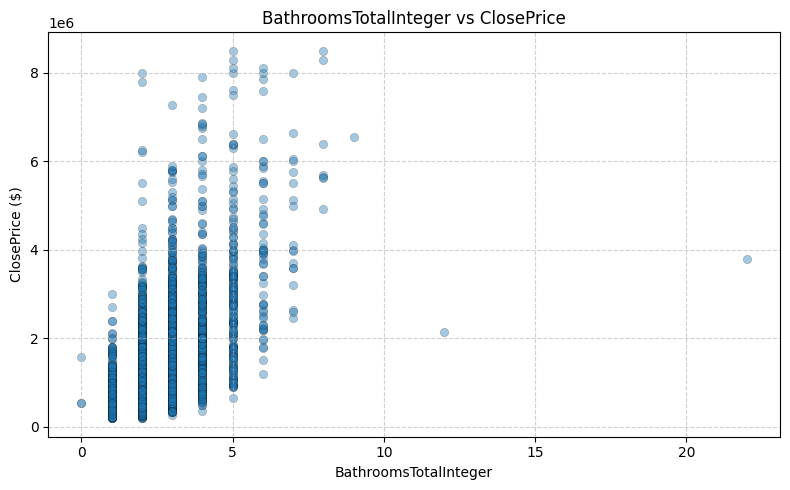

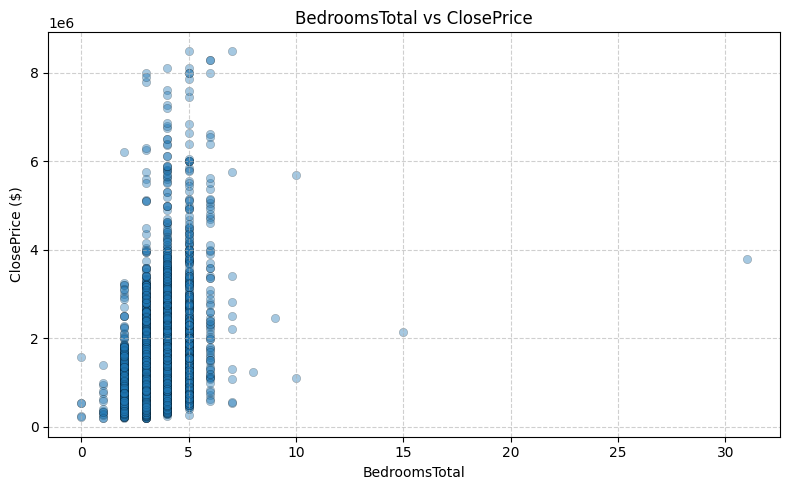

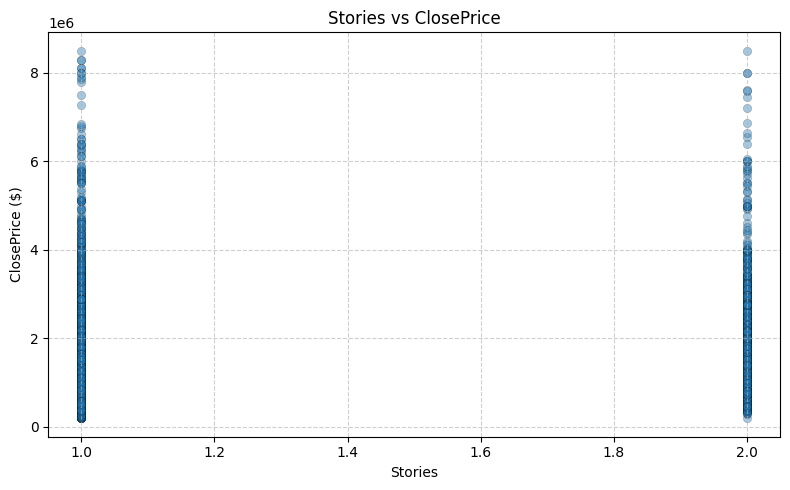

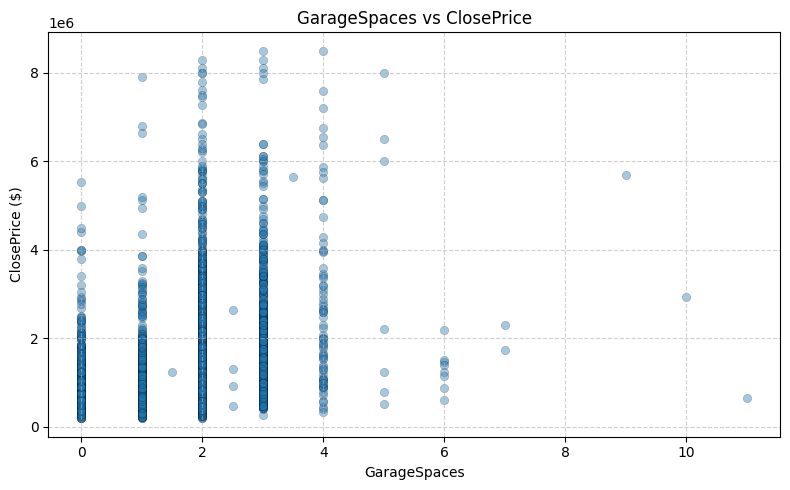

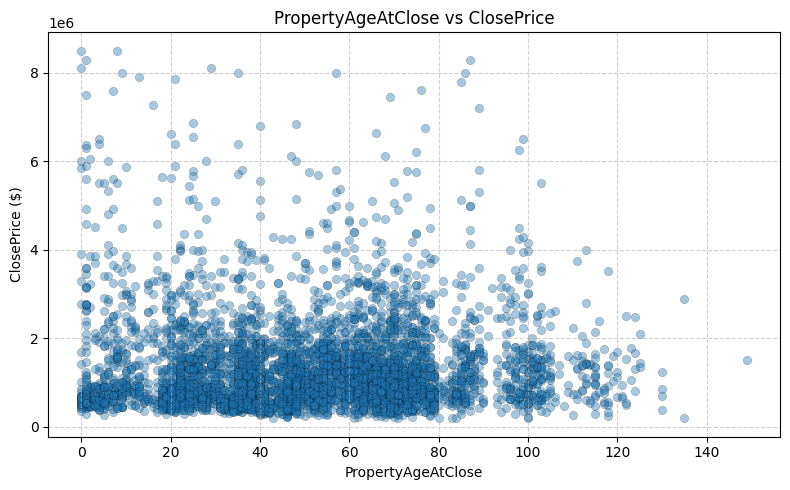

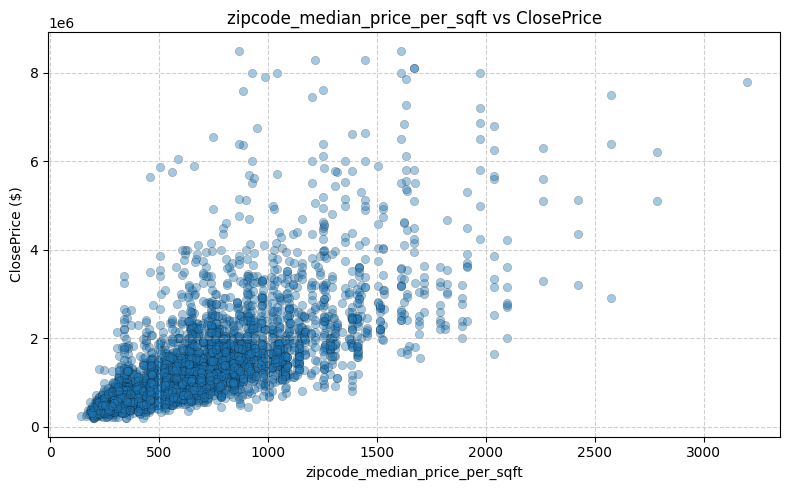

<Figure size 1000x500 with 0 Axes>

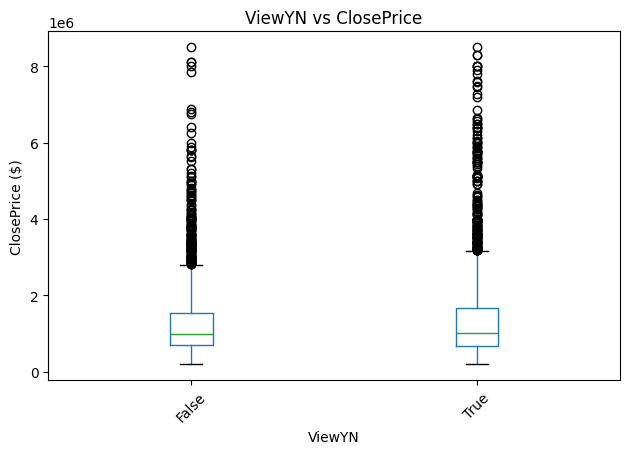

<Figure size 1000x500 with 0 Axes>

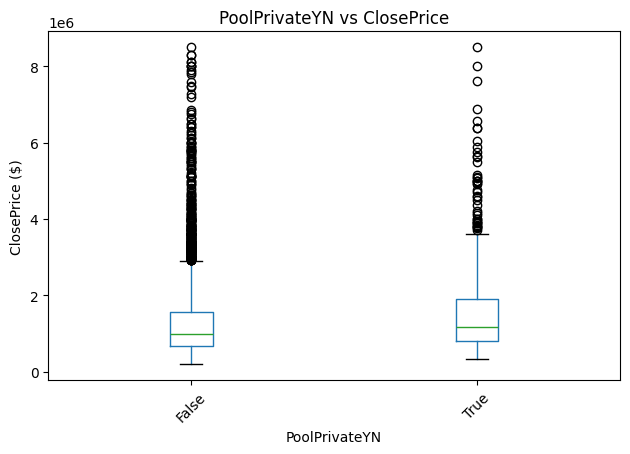

<Figure size 1000x500 with 0 Axes>

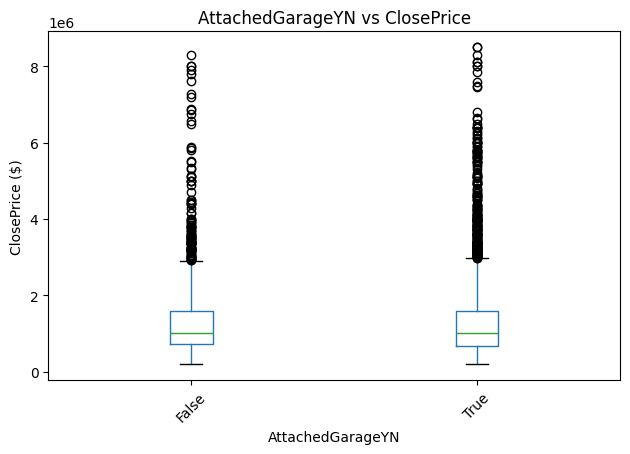

<Figure size 1000x500 with 0 Axes>

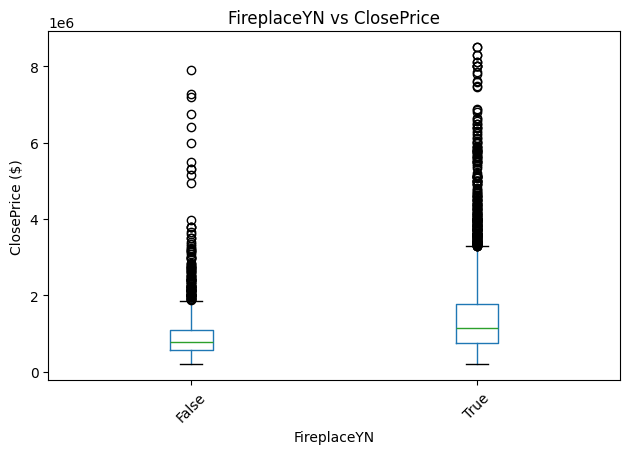

<Figure size 1000x500 with 0 Axes>

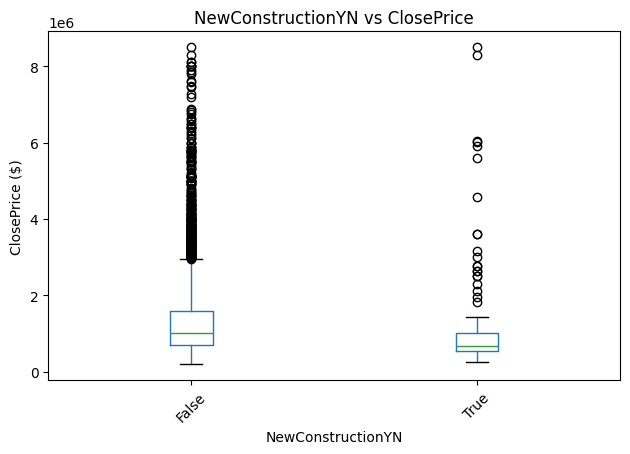

In [72]:
# 6) NOT IMPORTANT
# ORIGINAL FEATURES vs ClosePrice (numeric + categorical)

raw_feature_cols = df.drop(columns=['ClosePrice', 'CloseDate']).columns

num_features = df[raw_feature_cols].select_dtypes(include=[np.number]).columns
cat_features = df[raw_feature_cols].select_dtypes(exclude=[np.number]).columns

print("\nNumber of numeric features:", len(num_features))
print("Number of categorical features:", len(cat_features))

#numeric
#for numeric features, we create scatterplots to visualize their direct relationship with housing prices
for f in num_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(df[f], df['ClosePrice'], alpha=0.4, edgecolors='black', linewidth=0.3)
    plt.xlabel(f)
    plt.ylabel('ClosePrice ($)')
    plt.title(f'{f} vs ClosePrice')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

#categorical
#for categorical features with a manageable number of categories,
#we generate boxplots to compare price distributions across each category
for f in cat_features:
    if df[f].nunique() <= 15:
        plt.figure(figsize=(10, 5))
        df.boxplot(column='ClosePrice', by=f, grid=False, rot=45)
        plt.title(f'{f} vs ClosePrice')
        plt.suptitle("")
        plt.xlabel(f)
        plt.ylabel('ClosePrice ($)')
        plt.tight_layout()
        plt.show()


Replace `some_library` with the actual name of the library you wish to install. You can also specify a particular version of the library using `some_library==1.2.3` or install multiple libraries at once by listing them: `pip install library1 library2`.